# Voyage Analytics — Gender Classification Model

## Project Overview

This notebook develops the **Gender Classification** component of the Voyage Analytics project using the provided user dataset. The goal is to build a practical machine learning pipeline that can classify gender using relevant user information.

The workflow covers data exploration, cleaning, feature engineering, preprocessing, model training, evaluation, comparison, prediction, and model saving.

## Problem Statement

The `users.csv` dataset contains user information such as `code`, `company`, `name`, `gender`, and `age`. In this task, `gender` is treated as the target variable.

Before training, the dataset will be examined for missing values, duplicates, class distribution, and feature relevance. Only suitable information will be retained for model development.

## Objectives

- Explore and understand the user dataset
- Clean and prepare the data for modelling
- Engineer useful predictive features
- Train multiple classification models
- Evaluate models using Accuracy, Precision, Recall, and F1-score
- Compare the models and select the best performer
- Test the final model on unseen inputs
- Save the trained pipeline for future use
- Prepare reusable training logic for MLOps integration

## Dataset

**File:** `users.csv`  
**Domain:** Travel Analytics  
**Target:** `gender`

All dataset statistics and model results shown in this notebook will be generated from the actual data during execution.

## Expected Outcome

The final outcome will be a tested gender-classification pipeline with evaluation results, prediction capability, and saved model components that can later be integrated with **MLflow and Airflow**.

In [1]:
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


## Dataset Loading

The `users.csv` dataset is loaded from the project's data directory. A path check is performed before reading the file so that missing or incorrectly placed data can be identified immediately.

In [2]:
data_path = Path("../data/users.csv")

if not data_path.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {data_path.resolve()}"
    )

df = pd.read_csv(data_path)

print("Dataset loaded successfully.")
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")

display(df.head())

Dataset loaded successfully.
Dataset shape: 1340 rows × 5 columns


,code,company,name,gender,age
0,0,4You,Roy Braun,male,21
1,1,4You,Joseph Holsten,male,37
2,2,4You,Wilma Mcinnis,female,48
3,3,4You,Paula Daniel,female,23
4,4,4You,Patricia Carson,female,44


## Dataset Understanding

This section examines the structure and overall quality of the dataset before preprocessing. It reviews the dataset dimensions, data types, missing values, duplicate records, unique values, target classes, and basic statistical information.

In [5]:
print("DATASET OVERVIEW")
print("-" * 50)

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

print("\nCOLUMN NAMES")
print(df.columns.tolist())

print("\nDATA TYPES")
print(df.dtypes)

print("\nMISSING VALUES")
print(df.isnull().sum())

print("\nDUPLICATE ROWS")
print(df.duplicated().sum())

print("\nUNIQUE VALUES PER COLUMN")
print(df.nunique())

print("\nGENDER CLASSES")
print(df["gender"].value_counts(dropna=False))

print("\nNUMERICAL SUMMARY")
display(df.describe())

print("\nCATEGORICAL SUMMARY")
display(df.describe(include="object"))

DATASET OVERVIEW
--------------------------------------------------
Rows: 1340
Columns: 5

COLUMN NAMES
['code', 'company', 'name', 'gender', 'age']

DATA TYPES
code        int64
company    object
name       object
gender     object
age         int64
dtype: object

MISSING VALUES
code       0
company    0
name       0
gender     0
age        0
dtype: int64

DUPLICATE ROWS
0

UNIQUE VALUES PER COLUMN
code       1340
company       5
name       1338
gender        3
age          45
dtype: int64

GENDER CLASSES
gender
male      452
female    448
none      440
Name: count, dtype: int64

NUMERICAL SUMMARY


,code,age
count,1340.000000,1340.000000
mean,669.500000,42.742537
std,386.968991,12.869779
min,0.000000,21.000000
25%,334.750000,32.000000
50%,669.500000,42.000000
75%,1004.250000,54.000000
max,1339.000000,65.000000



CATEGORICAL SUMMARY


,company,name,gender
count,1340,1340,1340
unique,5,1338,3
top,4You,Charlotte Johnson,male
freq,453,2,452


## Exploratory Data Analysis

This section explores the main patterns within the user dataset through visual analysis. The distribution of gender, age, and company is examined, followed by comparisons between demographic and categorical attributes. These observations help identify class balance, possible relationships, and features that may be useful for model development.

## Gender Distribution

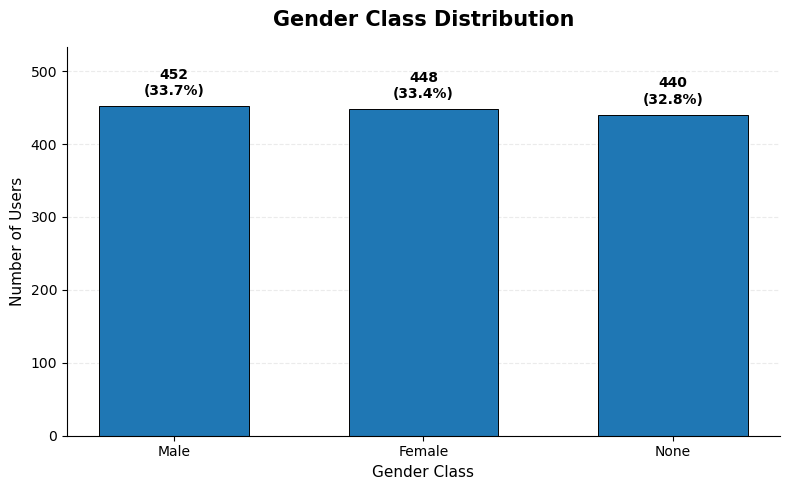

In [7]:
gender_counts = df["gender"].value_counts()
gender_percentages = (
    gender_counts / gender_counts.sum() * 100
)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    gender_counts.index.str.title(),
    gender_counts.values,
    width=0.6,
    edgecolor="black",
    linewidth=0.7
)

ax.set_title(
    "Gender Class Distribution",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Gender Class", fontsize=11)
ax.set_ylabel("Number of Users", fontsize=11)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

ax.set_axisbelow(True)

for bar, count, percentage in zip(
    bars,
    gender_counts.values,
    gender_percentages.values
):
    ax.annotate(
        f"{count:,}\n({percentage:.1f}%)",
        xy=(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height()
        ),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

ax.set_ylim(
    0,
    gender_counts.max() * 1.18
)

plt.tight_layout()
plt.show()

## Age Distribution: Histogram + Density Shape

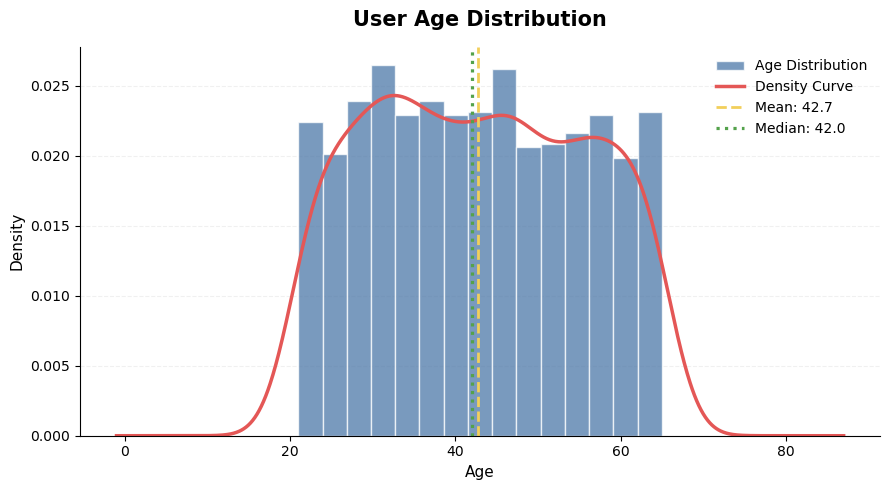

In [10]:
age_mean = df["age"].mean()
age_median = df["age"].median()

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    df["age"],
    bins=15,
    density=True,
    color="#4C78A8",
    alpha=0.75,
    edgecolor="white",
    linewidth=1.0,
    label="Age Distribution"
)

df["age"].plot(
    kind="kde",
    ax=ax,
    color="#E45756",
    linewidth=2.5,
    label="Density Curve"
)

ax.axvline(
    age_mean,
    color="#F2CF5B",
    linestyle="--",
    linewidth=2,
    label=f"Mean: {age_mean:.1f}"
)

ax.axvline(
    age_median,
    color="#54A24B",
    linestyle=":",
    linewidth=2.3,
    label=f"Median: {age_median:.1f}"
)

ax.set_title(
    "User Age Distribution",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Age", fontsize=11)
ax.set_ylabel("Density", fontsize=11)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.18
)

ax.set_axisbelow(True)

ax.legend(
    frameon=False,
    loc="upper right"
)

plt.tight_layout()
plt.show()

## Company Distribution: Horizontal Bar Chart

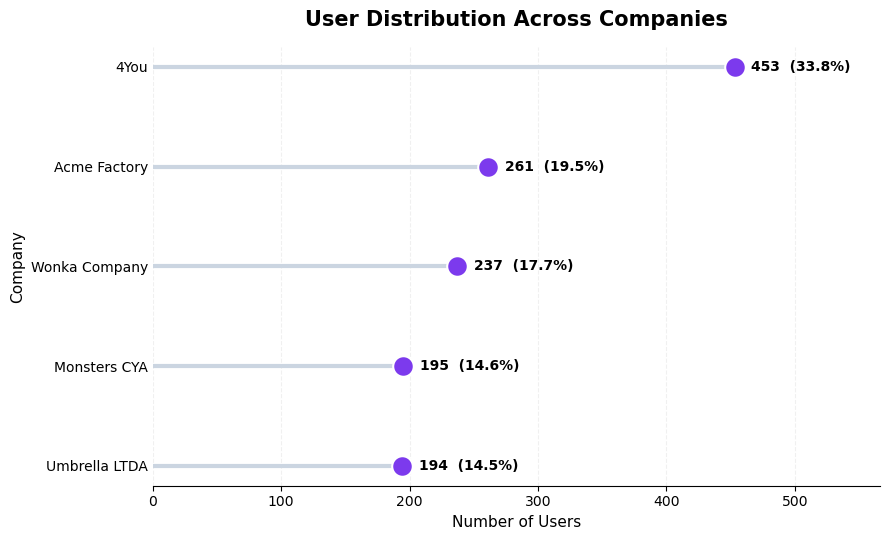

In [11]:
company_counts = (
    df["company"]
    .value_counts()
    .sort_values()
)

company_percentages = (
    company_counts / company_counts.sum() * 100
)

fig, ax = plt.subplots(figsize=(9, 5.5))

y_positions = np.arange(len(company_counts))

ax.hlines(
    y=y_positions,
    xmin=0,
    xmax=company_counts.values,
    color="#CBD5E1",
    linewidth=3
)

ax.scatter(
    company_counts.values,
    y_positions,
    s=220,
    color="#7C3AED",
    edgecolor="white",
    linewidth=1.5,
    zorder=3
)

for i, (count, percentage) in enumerate(
    zip(company_counts.values, company_percentages.values)
):
    ax.annotate(
        f"{count:,}  ({percentage:.1f}%)",
        xy=(count, i),
        xytext=(12, 0),
        textcoords="offset points",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

ax.set_yticks(y_positions)
ax.set_yticklabels(
    company_counts.index,
    fontsize=10
)

ax.set_title(
    "User Distribution Across Companies",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Number of Users",
    fontsize=11
)

ax.set_ylabel(
    "Company",
    fontsize=11
)

ax.set_xlim(
    0,
    company_counts.max() * 1.25
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.18
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.tick_params(
    axis="y",
    length=0
)

plt.tight_layout()
plt.show()

## Gender × Company: 100% Stacked Bar Chart

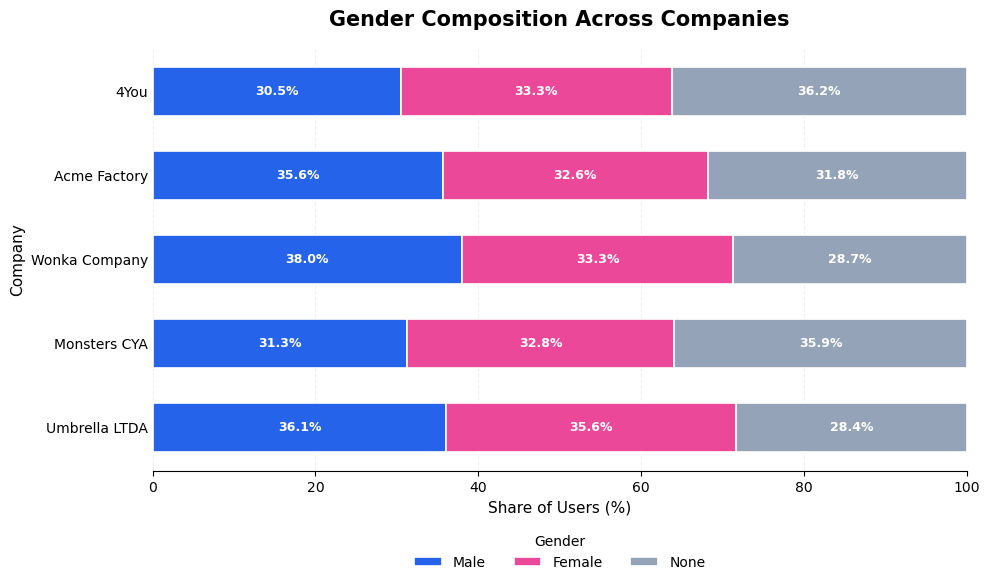

In [12]:
company_gender = pd.crosstab(
    df["company"],
    df["gender"],
    normalize="index"
).mul(100)

gender_order = ["male", "female", "none"]

company_gender = company_gender[
    [gender for gender in gender_order if gender in company_gender.columns]
]

company_gender = company_gender.loc[
    df["company"].value_counts().index
]

colors = [
    "#2563EB",
    "#EC4899",
    "#94A3B8"
]

fig, ax = plt.subplots(figsize=(10, 6))

left = np.zeros(len(company_gender))

for gender, color in zip(company_gender.columns, colors):
    values = company_gender[gender].values

    bars = ax.barh(
        company_gender.index,
        values,
        left=left,
        height=0.58,
        label=gender.title(),
        color=color,
        edgecolor="white",
        linewidth=1.2
    )

    for bar, value, start in zip(
        bars,
        values,
        left
    ):
        if value >= 7:
            ax.text(
                start + value / 2,
                bar.get_y() + bar.get_height() / 2,
                f"{value:.1f}%",
                ha="center",
                va="center",
                fontsize=9,
                fontweight="bold",
                color="white"
            )

    left += values

ax.set_title(
    "Gender Composition Across Companies",
    fontsize=15,
    fontweight="bold",
    pad=16
)

ax.set_xlabel(
    "Share of Users (%)",
    fontsize=11
)

ax.set_ylabel(
    "Company",
    fontsize=11
)

ax.set_xlim(0, 100)

ax.set_xticks(
    np.arange(0, 101, 20)
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.18
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.tick_params(
    axis="y",
    length=0
)

ax.legend(
    title="Gender",
    ncols=3,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    frameon=False
)

ax.invert_yaxis()

plt.tight_layout()
plt.show()

## Age × Gender: Violin Plot

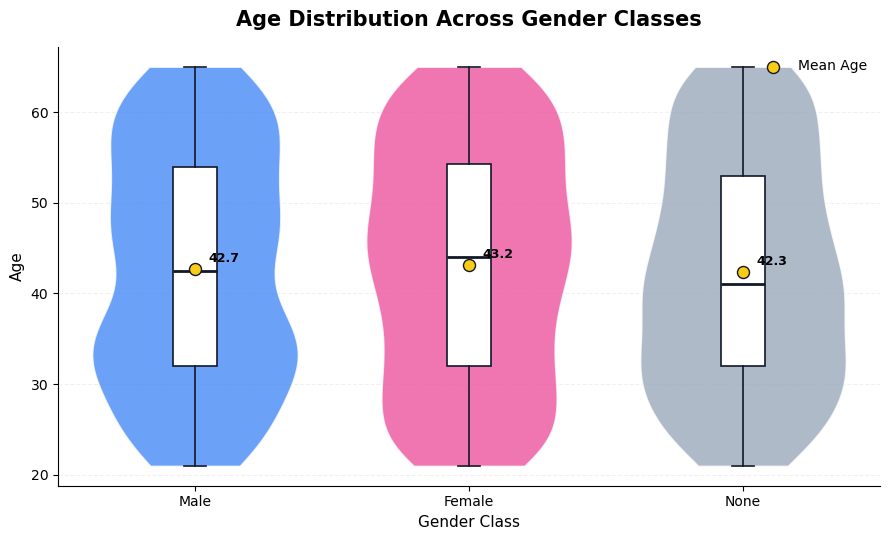

In [13]:
gender_order = ["male", "female", "none"]

age_groups = [
    df.loc[df["gender"] == gender, "age"].values
    for gender in gender_order
]

fig, ax = plt.subplots(figsize=(9, 5.5))

violins = ax.violinplot(
    age_groups,
    positions=np.arange(1, len(gender_order) + 1),
    widths=0.75,
    showmeans=False,
    showmedians=False,
    showextrema=False
)

violin_colors = ["#3B82F6", "#EC4899", "#94A3B8"]

for body, color in zip(violins["bodies"], violin_colors):
    body.set_facecolor(color)
    body.set_edgecolor("white")
    body.set_alpha(0.75)

box = ax.boxplot(
    age_groups,
    positions=np.arange(1, len(gender_order) + 1),
    widths=0.16,
    patch_artist=True,
    showfliers=False,
    medianprops={
        "color": "#111827",
        "linewidth": 2
    },
    boxprops={
        "facecolor": "white",
        "edgecolor": "#111827",
        "linewidth": 1.2
    },
    whiskerprops={
        "color": "#111827",
        "linewidth": 1.2
    },
    capprops={
        "color": "#111827",
        "linewidth": 1.2
    }
)

means = [
    values.mean()
    for values in age_groups
]

ax.scatter(
    np.arange(1, len(gender_order) + 1),
    means,
    s=75,
    color="#FACC15",
    edgecolor="#111827",
    linewidth=1,
    zorder=4,
    label="Mean Age"
)

for x, mean in zip(
    np.arange(1, len(gender_order) + 1),
    means
):
    ax.annotate(
        f"{mean:.1f}",
        (x, mean),
        xytext=(10, 5),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold"
    )

ax.set_xticks(
    np.arange(1, len(gender_order) + 1)
)

ax.set_xticklabels(
    ["Male", "Female", "None"]
)

ax.set_title(
    "Age Distribution Across Gender Classes",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Gender Class",
    fontsize=11
)

ax.set_ylabel(
    "Age",
    fontsize=11
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.18
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    frameon=False,
    loc="upper right"
)

plt.tight_layout()
plt.show()

## Data Cleaning

The dataset is cleaned before feature engineering and model training. A separate working copy is created to preserve the original data. Text fields are standardized, duplicate records are removed, and records with an undefined gender label are excluded because they do not provide a valid target for the binary gender-classification task. The cleaned dataset is then validated to ensure that only usable observations remain.

In [17]:
clean_df = df.copy()

initial_rows = len(clean_df)

clean_df["company"] = clean_df["company"].astype(str).str.strip()
clean_df["name"] = clean_df["name"].astype(str).str.strip()
clean_df["gender"] = clean_df["gender"].astype(str).str.strip().str.lower()

duplicates_before = clean_df.duplicated().sum()
clean_df = clean_df.drop_duplicates().copy()

undefined_gender = clean_df["gender"].eq("none").sum()
clean_df = clean_df[clean_df["gender"].isin(["male", "female"])].copy()

clean_df = clean_df.dropna(
    subset=["company", "name", "gender", "age"]
)

clean_df = clean_df.reset_index(drop=True)

print("DATA CLEANING SUMMARY")
print("-" * 50)
print(f"Initial records: {initial_rows}")
print(f"Duplicate records removed: {duplicates_before}")
print(f"Undefined gender records removed: {undefined_gender}")
print(f"Final records: {len(clean_df)}")

print("\nREMAINING GENDER CLASSES")
print(clean_df["gender"].value_counts())

print("\nMISSING VALUES AFTER CLEANING")
print(clean_df.isnull().sum())

print("\nFINAL DATASET SHAPE")
print(clean_df.shape)

display(clean_df.head())

DATA CLEANING SUMMARY
--------------------------------------------------
Initial records: 1340
Duplicate records removed: 0
Undefined gender records removed: 440
Final records: 900

REMAINING GENDER CLASSES
gender
male      452
female    448
Name: count, dtype: int64

MISSING VALUES AFTER CLEANING
code       0
company    0
name       0
gender     0
age        0
dtype: int64

FINAL DATASET SHAPE
(900, 5)


,code,company,name,gender,age
0,0,4You,Roy Braun,male,21
1,1,4You,Joseph Holsten,male,37
2,2,4You,Wilma Mcinnis,female,48
3,3,4You,Paula Daniel,female,23
4,4,4You,Patricia Carson,female,44


## Feature Engineering

Relevant features are prepared from the cleaned user data to improve its suitability for classification. The unique user code is excluded from modelling, while useful characteristics are derived from the name field. Age and company information are retained as additional candidate predictors. The target variable remains separate from all predictive features to prevent data leakage.

In [18]:
feature_df = clean_df.copy()

feature_df["name"] = feature_df["name"].str.lower().str.strip()

feature_df["first_name"] = feature_df["name"].str.split().str[0]

feature_df["first_name_length"] = (
    feature_df["first_name"].str.len()
)

feature_df["last_letter"] = (
    feature_df["first_name"].str[-1]
)

feature_df["vowel_count"] = (
    feature_df["first_name"]
    .str.count(r"[aeiou]")
)

feature_df["vowel_ratio"] = (
    feature_df["vowel_count"]
    / feature_df["first_name_length"].replace(0, np.nan)
).fillna(0)

feature_df["age"] = pd.to_numeric(
    feature_df["age"],
    errors="coerce"
)

feature_df = feature_df.dropna(
    subset=["age", "first_name"]
).reset_index(drop=True)

model_features = [
    "first_name",
    "first_name_length",
    "last_letter",
    "vowel_count",
    "vowel_ratio",
    "age",
    "company"
]

X = feature_df[model_features].copy()
y = feature_df["gender"].copy()

print("FEATURE ENGINEERING SUMMARY")
print("-" * 50)

print(f"Records available: {len(feature_df)}")
print(f"Number of model features: {len(model_features)}")

print("\nMODEL FEATURES")
print(model_features)

print("\nFEATURE DATA TYPES")
print(X.dtypes)

print("\nTARGET DISTRIBUTION")
print(y.value_counts())

print("\nMISSING VALUES IN FEATURES")
print(X.isnull().sum())

display(X.head())

FEATURE ENGINEERING SUMMARY
--------------------------------------------------
Records available: 900
Number of model features: 7

MODEL FEATURES
['first_name', 'first_name_length', 'last_letter', 'vowel_count', 'vowel_ratio', 'age', 'company']

FEATURE DATA TYPES
first_name            object
first_name_length      int64
last_letter           object
vowel_count            int64
vowel_ratio          float64
age                    int64
company               object
dtype: object

TARGET DISTRIBUTION
gender
male      452
female    448
Name: count, dtype: int64

MISSING VALUES IN FEATURES
first_name           0
first_name_length    0
last_letter          0
vowel_count          0
vowel_ratio          0
age                  0
company              0
dtype: int64


,first_name,first_name_length,last_letter,vowel_count,vowel_ratio,age,company
0,roy,3,y,1,0.333333,21,4You
1,joseph,6,h,2,0.333333,37,4You
2,wilma,5,a,2,0.400000,48,4You
3,paula,5,a,3,0.600000,23,4You
4,patricia,8,a,4,0.500000,44,4You


## Preprocessing

The engineered features contain text, categorical, and numerical information, so each feature type requires a suitable transformation. First names are converted into character-level TF-IDF features, categorical attributes are one-hot encoded, and numerical features are standardized. These transformations are combined into a single preprocessing pipeline for consistent model training and prediction.

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

text_feature = "first_name"

categorical_features = [
    "last_letter",
    "company"
]

numerical_features = [
    "first_name_length",
    "vowel_count",
    "vowel_ratio",
    "age"
]

name_vectorizer = TfidfVectorizer(
    analyzer="char",
    ngram_range=(2, 4),
    lowercase=True,
    min_df=2,
    sublinear_tf=True
)

categorical_encoder = OneHotEncoder(
    handle_unknown="ignore"
)

numerical_scaler = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        (
            "name_tfidf",
            name_vectorizer,
            text_feature
        ),
        (
            "categorical",
            categorical_encoder,
            categorical_features
        ),
        (
            "numerical",
            numerical_scaler,
            numerical_features
        )
    ],
    remainder="drop"
)

print("PREPROCESSING CONFIGURATION")
print("-" * 50)

print(f"Text feature: {text_feature}")
print(f"Categorical features: {categorical_features}")
print(f"Numerical features: {numerical_features}")

print("\nTransformations:")
print("First name       -> Character-level TF-IDF")
print("Categorical data -> One-Hot Encoding")
print("Numerical data   -> Standard Scaling")

print("\nPreprocessor created successfully.")

PREPROCESSING CONFIGURATION
--------------------------------------------------
Text feature: first_name
Categorical features: ['last_letter', 'company']
Numerical features: ['first_name_length', 'vowel_count', 'vowel_ratio', 'age']

Transformations:
First name       -> Character-level TF-IDF
Categorical data -> One-Hot Encoding
Numerical data   -> Standard Scaling

Preprocessor created successfully.


## Train/Test Split

The prepared dataset is divided into training and testing subsets to evaluate the models on unseen data. An 80:20 split is used, while stratification preserves the original gender-class distribution in both subsets. A fixed random state ensures that the split remains reproducible across repeated executions.

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("TRAIN / TEST SPLIT SUMMARY")
print("-" * 50)

print(f"Total records: {len(X)}")
print(f"Training records: {len(X_train)}")
print(f"Testing records: {len(X_test)}")

print("\nTRAINING CLASS DISTRIBUTION")
train_distribution = pd.DataFrame({
    "Count": y_train.value_counts(),
    "Percentage": y_train.value_counts(normalize=True).mul(100).round(2)
})
display(train_distribution)

print("TESTING CLASS DISTRIBUTION")
test_distribution = pd.DataFrame({
    "Count": y_test.value_counts(),
    "Percentage": y_test.value_counts(normalize=True).mul(100).round(2)
})
display(test_distribution)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

TRAIN / TEST SPLIT SUMMARY
--------------------------------------------------
Total records: 900
Training records: 720
Testing records: 180

TRAINING CLASS DISTRIBUTION


,Count,Percentage
gender,,
male,362,50.28
female,358,49.72


TESTING CLASS DISTRIBUTION


,Count,Percentage
gender,,
female,90,50.0
male,90,50.0


X_train shape: (720, 7)
X_test shape: (180, 7)
y_train shape: (720,)
y_test shape: (180,)


## Multiple Model Training

Multiple classification algorithms are trained to compare different learning approaches on the same gender-classification task. Logistic Regression and Linear SVM are trained using standardized numerical features, while Multinomial Naive Bayes uses non-negative numerical scaling to satisfy its input requirements. Each model combines preprocessing and classification within a pipeline, preventing preprocessing leakage and ensuring reproducible training.

In [22]:
from sklearn.preprocessing import MinMaxScaler
from time import perf_counter

standard_preprocessor = ColumnTransformer(
    transformers=[
        (
            "name_tfidf",
            TfidfVectorizer(
                analyzer="char",
                ngram_range=(2, 4),
                min_df=2,
                sublinear_tf=True
            ),
            "first_name"
        ),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features
        )
    ],
    remainder="drop"
)

nb_preprocessor = ColumnTransformer(
    transformers=[
        (
            "name_tfidf",
            TfidfVectorizer(
                analyzer="char",
                ngram_range=(2, 4),
                min_df=2,
                sublinear_tf=True
            ),
            "first_name"
        ),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            MinMaxScaler(),
            numerical_features
        )
    ],
    remainder="drop"
)

model_configs = {
    "Logistic Regression": {
        "preprocessor": standard_preprocessor,
        "classifier": LogisticRegression(
            max_iter=2000,
            random_state=RANDOM_STATE
        )
    },

    "Multinomial Naive Bayes": {
        "preprocessor": nb_preprocessor,
        "classifier": MultinomialNB()
    },

    "Linear SVM": {
        "preprocessor": standard_preprocessor,
        "classifier": LinearSVC(
            max_iter=5000,
            random_state=RANDOM_STATE
        )
    }
}

trained_models = {}
training_summary = []

for model_name, config in model_configs.items():

    pipeline = Pipeline([
        ("preprocessor", config["preprocessor"]),
        ("classifier", config["classifier"])
    ])

    start_time = perf_counter()

    pipeline.fit(
        X_train,
        y_train
    )

    training_time = perf_counter() - start_time

    trained_models[model_name] = pipeline

    training_summary.append({
        "Model": model_name,
        "Status": "Trained",
        "Training Samples": len(X_train),
        "Training Time (s)": round(training_time, 4)
    })

training_summary_df = pd.DataFrame(training_summary)

print("MODEL TRAINING COMPLETE")
print("-" * 60)
print(f"Models trained: {len(trained_models)}")
print(f"Training samples: {len(X_train)}")
print(f"Input features: {X_train.shape[1]}")

display(training_summary_df)

MODEL TRAINING COMPLETE
------------------------------------------------------------
Models trained: 3
Training samples: 720
Input features: 7


,Model,Status,Training Samples,Training Time (s)
0,Logistic Regression,Trained,720,0.0750
1,Multinomial Naive Bayes,Trained,720,0.0094
2,Linear SVM,Trained,720,0.0227


## Model Evaluation

The trained models are evaluated on the unseen test dataset using Accuracy, Precision, Recall, and F1-score. These metrics provide a broader assessment than accuracy alone by considering both correct predictions and classification errors. The results are stored for direct comparison and later best-model selection.

In [23]:
evaluation_results = []
model_predictions = {}

for model_name, model in trained_models.items():

    predictions = model.predict(X_test)

    model_predictions[model_name] = predictions

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        average="weighted",
        zero_division=0
    )

    evaluation_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

evaluation_df = pd.DataFrame(
    evaluation_results
).sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]

evaluation_display = evaluation_df.copy()

evaluation_display[metric_columns] = (
    evaluation_display[metric_columns] * 100
).round(2)

print("MODEL EVALUATION RESULTS")
print("-" * 60)
print(f"Test samples evaluated: {len(X_test)}")

display(
    evaluation_display.style.format({
        "Accuracy": "{:.2f}%",
        "Precision": "{:.2f}%",
        "Recall": "{:.2f}%",
        "F1-Score": "{:.2f}%"
    })
)

MODEL EVALUATION RESULTS
------------------------------------------------------------
Test samples evaluated: 180


,Model,Accuracy,Precision,Recall,F1-Score
0,Linear SVM,90.00%,90.32%,90.00%,89.98%
1,Multinomial Naive Bayes,86.11%,86.22%,86.11%,86.10%
2,Logistic Regression,85.56%,85.84%,85.56%,85.53%


## Model Comparison

The performance of the trained classifiers is compared across Accuracy, Precision, Recall, and F1-score. This visual comparison makes it easier to identify performance differences between the models and provides supporting evidence for selecting the final classifier.

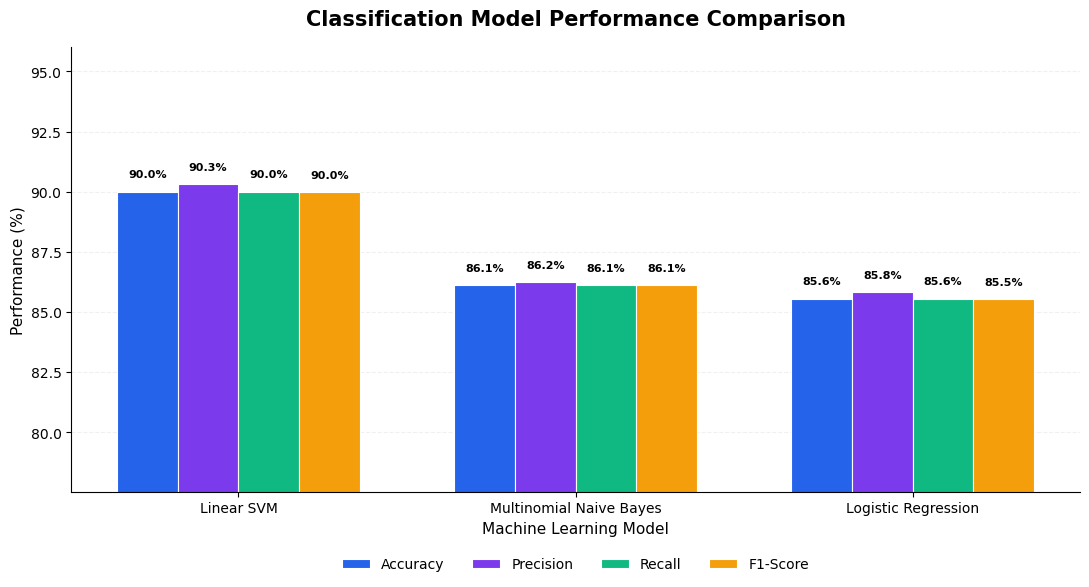

In [24]:
comparison_df = evaluation_df.copy()

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]

model_names = comparison_df["Model"].tolist()

x = np.arange(len(model_names))
bar_width = 0.18

metric_colors = [
    "#2563EB",
    "#7C3AED",
    "#10B981",
    "#F59E0B"
]

fig, ax = plt.subplots(figsize=(11, 6))

for i, (metric, color) in enumerate(
    zip(metrics, metric_colors)
):
    values = comparison_df[metric].values * 100

    positions = (
        x + (i - 1.5) * bar_width
    )

    bars = ax.bar(
        positions,
        values,
        width=bar_width,
        label=metric,
        color=color,
        edgecolor="white",
        linewidth=0.8
    )

    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{value:.1f}%",
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="bold"
        )

ax.set_title(
    "Classification Model Performance Comparison",
    fontsize=15,
    fontweight="bold",
    pad=16
)

ax.set_xlabel(
    "Machine Learning Model",
    fontsize=11
)

ax.set_ylabel(
    "Performance (%)",
    fontsize=11
)

ax.set_xticks(x)
ax.set_xticklabels(model_names)

ax.set_ylim(
    max(0, comparison_df[metrics].min().min() * 100 - 8),
    96
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.18
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    ncols=4,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    frameon=False
)

plt.tight_layout()
plt.show()

## Best Model Selection

The final classifier is selected objectively using the F1-score, which provides a balanced measure of precision and recall. The model with the highest test F1-score is identified automatically and retained as the final model for subsequent analysis, prediction, and model persistence.

In [25]:
best_model_row = evaluation_df.loc[
    evaluation_df["F1-Score"].idxmax()
]

best_model_name = best_model_row["Model"]

best_model = trained_models[
    best_model_name
]

best_accuracy = best_model_row["Accuracy"] * 100
best_precision = best_model_row["Precision"] * 100
best_recall = best_model_row["Recall"] * 100
best_f1 = best_model_row["F1-Score"] * 100

best_model_summary = pd.DataFrame({
    "Selected Model": [best_model_name],
    "Accuracy": [best_accuracy],
    "Precision": [best_precision],
    "Recall": [best_recall],
    "F1-Score": [best_f1]
})

print("BEST MODEL SELECTION")
print("-" * 60)
print(f"Selection criterion: Highest F1-Score")
print(f"Selected model: {best_model_name}")

display(
    best_model_summary.style.format({
        "Accuracy": "{:.2f}%",
        "Precision": "{:.2f}%",
        "Recall": "{:.2f}%",
        "F1-Score": "{:.2f}%"
    })
)

BEST MODEL SELECTION
------------------------------------------------------------
Selection criterion: Highest F1-Score
Selected model: Linear SVM


,Selected Model,Accuracy,Precision,Recall,F1-Score
0,Linear SVM,90.00%,90.32%,90.00%,89.98%


## Confusion Matrix and Classification Report

The selected model is examined in greater detail using a confusion matrix and class-level performance metrics. The confusion matrix shows correct and incorrect predictions for each gender class, while the classification report summarizes precision, recall, and F1-score individually for female and male users.

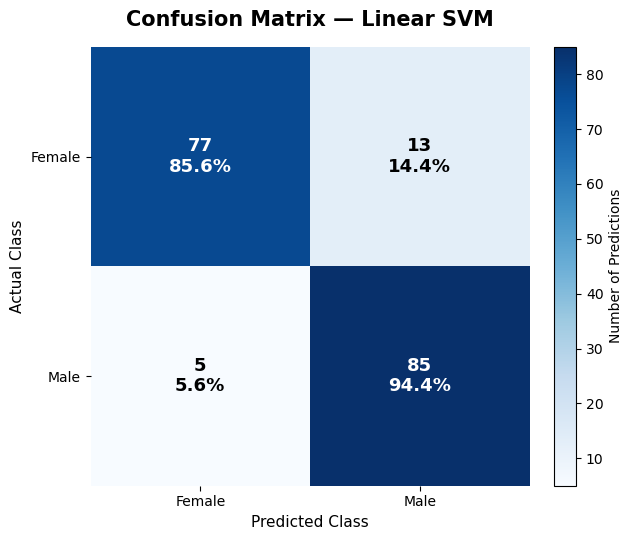

CLASSIFICATION REPORT
------------------------------------------------------------
Selected model: Linear SVM
Test samples: 180


,precision,recall,f1-score,support
female,93.90%,85.56%,89.53%,90
male,86.73%,94.44%,90.43%,90
accuracy,90.00%,90.00%,90.00%,1
macro avg,90.32%,90.00%,89.98%,180
weighted avg,90.32%,90.00%,89.98%,180


In [26]:
best_predictions = best_model.predict(X_test)

class_labels = ["female", "male"]

cm = confusion_matrix(
    y_test,
    best_predictions,
    labels=class_labels
)

fig, ax = plt.subplots(figsize=(7, 5.5))

im = ax.imshow(
    cm,
    cmap="Blues"
)

ax.set_xticks(
    np.arange(len(class_labels))
)

ax.set_yticks(
    np.arange(len(class_labels))
)

ax.set_xticklabels(
    [label.title() for label in class_labels]
)

ax.set_yticklabels(
    [label.title() for label in class_labels]
)

ax.set_xlabel(
    "Predicted Class",
    fontsize=11
)

ax.set_ylabel(
    "Actual Class",
    fontsize=11
)

ax.set_title(
    f"Confusion Matrix — {best_model_name}",
    fontsize=15,
    fontweight="bold",
    pad=15
)

threshold = cm.max() / 2

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):

        count = cm[i, j]

        percentage = (
            count / cm[i].sum()
        ) * 100

        ax.text(
            j,
            i,
            f"{count}\n{percentage:.1f}%",
            ha="center",
            va="center",
            fontsize=13,
            fontweight="bold",
            color="white" if count > threshold else "black"
        )

for spine in ax.spines.values():
    spine.set_visible(False)

fig.colorbar(
    im,
    ax=ax,
    fraction=0.046,
    pad=0.04,
    label="Number of Predictions"
)

plt.tight_layout()
plt.show()

report = classification_report(
    y_test,
    best_predictions,
    labels=class_labels,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).T

report_display = (
    report_df
    .loc[
        ["female", "male", "accuracy", "macro avg", "weighted avg"]
    ]
    .copy()
)

for column in [
    "precision",
    "recall",
    "f1-score"
]:
    report_display[column] = (
        report_display[column] * 100
    )

print("CLASSIFICATION REPORT")
print("-" * 60)
print(f"Selected model: {best_model_name}")
print(f"Test samples: {len(y_test)}")

display(
    report_display.style.format({
        "precision": "{:.2f}%",
        "recall": "{:.2f}%",
        "f1-score": "{:.2f}%",
        "support": "{:.0f}"
    })
)

## Test Predictions

The selected model is tested on sample user records that were not used directly as training inputs. The same feature-engineering logic applied during model development is reproduced before inference, ensuring that new records match the structure expected by the trained pipeline. The resulting predictions demonstrate the complete flow from raw user information to the final predicted class.

In [27]:
def prepare_prediction_data(records):
    prediction_df = pd.DataFrame(records).copy()

    prediction_df["name"] = (
        prediction_df["name"]
        .astype(str)
        .str.lower()
        .str.strip()
    )

    prediction_df["company"] = (
        prediction_df["company"]
        .astype(str)
        .str.strip()
    )

    prediction_df["first_name"] = (
        prediction_df["name"]
        .str.split()
        .str[0]
    )

    prediction_df["first_name_length"] = (
        prediction_df["first_name"]
        .str.len()
    )

    prediction_df["last_letter"] = (
        prediction_df["first_name"]
        .str[-1]
    )

    prediction_df["vowel_count"] = (
        prediction_df["first_name"]
        .str.count(r"[aeiou]")
    )

    prediction_df["vowel_ratio"] = (
        prediction_df["vowel_count"]
        / prediction_df["first_name_length"].replace(0, np.nan)
    ).fillna(0)

    prediction_df["age"] = pd.to_numeric(
        prediction_df["age"],
        errors="coerce"
    )

    return prediction_df[model_features]


sample_users = [
    {
        "name": "Michael Anderson",
        "age": 29,
        "company": "4You"
    },
    {
        "name": "Sophia Williams",
        "age": 35,
        "company": "Acme Factory"
    },
    {
        "name": "Daniel Thompson",
        "age": 46,
        "company": "Wonka Company"
    },
    {
        "name": "Olivia Martin",
        "age": 31,
        "company": "Umbrella LTDA"
    }
]

sample_features = prepare_prediction_data(
    sample_users
)

sample_predictions = best_model.predict(
    sample_features
)

prediction_results = pd.DataFrame(
    sample_users
)

prediction_results["Predicted Gender"] = (
    pd.Series(sample_predictions)
    .str.title()
)

print("SAMPLE PREDICTIONS")
print("-" * 60)
print(f"Model used: {best_model_name}")
print(f"Samples predicted: {len(prediction_results)}")

display(prediction_results)

SAMPLE PREDICTIONS
------------------------------------------------------------
Model used: Linear SVM
Samples predicted: 4


,name,age,company,Predicted Gender
0,Michael Anderson,29,4You,Male
1,Sophia Williams,35,Acme Factory,Female
2,Daniel Thompson,46,Wonka Company,Male
3,Olivia Martin,31,Umbrella LTDA,Female


## Save Final Model

The selected classification pipeline is saved as a reusable model artifact for future inference and MLOps integration. Storing the complete fitted pipeline preserves both preprocessing and classification logic, allowing new feature-engineered records to be processed consistently without retraining the model.


In [28]:
from pathlib import Path
import joblib

models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

model_path = models_dir / "gender_classification_model.joblib"

joblib.dump(
    best_model,
    model_path
)

model_size_mb = model_path.stat().st_size / (1024 ** 2)

loaded_model = joblib.load(model_path)

verification_predictions = loaded_model.predict(X_test)

model_verified = np.array_equal(
    best_predictions,
    verification_predictions
)

print("MODEL PERSISTENCE SUMMARY")
print("-" * 60)
print(f"Model: {best_model_name}")
print(f"Artifact: {model_path.name}")
print(f"Location: {model_path}")
print(f"File size: {model_size_mb:.3f} MB")
print(f"Reload verification: {'PASSED' if model_verified else 'FAILED'}")

if not model_verified:
    raise RuntimeError(
        "Reloaded model predictions do not match the original model."
    )

MODEL PERSISTENCE SUMMARY
------------------------------------------------------------
Model: Linear SVM
Artifact: gender_classification_model.joblib
Location: ../models/gender_classification_model.joblib
File size: 0.030 MB
Reload verification: PASSED


## Save Preprocessing Components

The fitted preprocessing component is extracted from the selected model pipeline and stored separately for reproducibility and downstream integration. This artifact preserves the learned TF-IDF vocabulary, categorical encoding, and numerical scaling required to transform future records consistently with the training process.

In [29]:
preprocessor_path = models_dir / "gender_preprocessor.joblib"

fitted_preprocessor = best_model.named_steps["preprocessor"]

joblib.dump(
    fitted_preprocessor,
    preprocessor_path
)

preprocessor_size_mb = (
    preprocessor_path.stat().st_size / (1024 ** 2)
)

loaded_preprocessor = joblib.load(
    preprocessor_path
)

original_transformed = fitted_preprocessor.transform(
    X_test
)

reloaded_transformed = loaded_preprocessor.transform(
    X_test
)

if hasattr(original_transformed, "toarray"):
    original_check = original_transformed.toarray()
else:
    original_check = np.asarray(original_transformed)

if hasattr(reloaded_transformed, "toarray"):
    reloaded_check = reloaded_transformed.toarray()
else:
    reloaded_check = np.asarray(reloaded_transformed)

preprocessor_verified = np.allclose(
    original_check,
    reloaded_check
)

print("PREPROCESSOR PERSISTENCE SUMMARY")
print("-" * 60)
print(f"Artifact: {preprocessor_path.name}")
print(f"Location: {preprocessor_path}")
print(f"File size: {preprocessor_size_mb:.3f} MB")
print(
    "Reload verification:",
    "PASSED" if preprocessor_verified else "FAILED"
)

if not preprocessor_verified:
    raise RuntimeError(
        "Reloaded preprocessing output does not match the original."
    )

PREPROCESSOR PERSISTENCE SUMMARY
------------------------------------------------------------
Artifact: gender_preprocessor.joblib
Location: ../models/gender_preprocessor.joblib
File size: 0.021 MB
Reload verification: PASSED


## Results and Conclusion

The gender-classification workflow was completed using 1,340 user records. After removing 440 records with an undefined gender label, 900 valid observations remained for binary classification, with 452 male and 448 female records.

The data was transformed using name-based character TF-IDF features, categorical encoding, and numerical scaling. Three classification algorithms were evaluated on a stratified 20% test set containing 180 unseen records.

Linear SVM achieved the strongest overall performance, reaching 90.00% accuracy, 90.32% weighted precision, 90.00% weighted recall, and 89.98% weighted F1-score. It outperformed both Multinomial Naive Bayes and Logistic Regression on the evaluated metrics.

The confusion matrix showed 162 correct predictions and 18 misclassifications. The model correctly identified 77 of 90 female records and 85 of 90 male records, indicating stronger recall for the male class than the female class.

The final Linear SVM pipeline and fitted preprocessing component were successfully saved and verified after reloading. These artifacts provide a reproducible foundation for prediction and subsequent MLflow and Airflow integration.

In [30]:
final_summary = pd.DataFrame({
    "Metric": [
        "Original Records",
        "Training-Ready Records",
        "Training Samples",
        "Testing Samples",
        "Selected Model",
        "Test Accuracy",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1-Score",
        "Correct Predictions",
        "Incorrect Predictions"
    ],
    "Result": [
        len(df),
        len(feature_df),
        len(X_train),
        len(X_test),
        best_model_name,
        f"{best_accuracy:.2f}%",
        f"{best_precision:.2f}%",
        f"{best_recall:.2f}%",
        f"{best_f1:.2f}%",
        int((best_predictions == y_test).sum()),
        int((best_predictions != y_test).sum())
    ]
})

print("FINAL MODEL SUMMARY")
print("-" * 60)

display(
    final_summary.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "left"
    })
)

FINAL MODEL SUMMARY
------------------------------------------------------------


Metric,Result
Original Records,1340
Training-Ready Records,900
Training Samples,720
Testing Samples,180
Selected Model,Linear SVM
Test Accuracy,90.00%
Weighted Precision,90.32%
Weighted Recall,90.00%
Weighted F1-Score,89.98%
Correct Predictions,162


## Reusable Training Script

The completed modelling workflow is converted into a reusable Python training script for downstream MLOps integration. The script independently loads and cleans the user dataset, performs feature engineering, creates the preprocessing pipeline, trains the selected Linear SVM classifier, evaluates it on a stratified test set, and saves the resulting model artifacts. This provides a reproducible training entry point that can later be executed and tracked through MLflow and orchestrated through Airflow.